In [19]:
import torch
import numpy as np
import json
import os
import trimesh
import skimage.measure
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 1. Load Configuration and Model

In [20]:
# Paths
experiment_dir = "/home/jakaria/INR/Deep3DComp/examples/CALSNIC_control_L_local"
specs_file = os.path.join(experiment_dir, "specs.json")

# Load specs
with open(specs_file, 'r') as f:
    specs = json.load(f)

print("Configuration:")
print(f"  Global Code Size: {specs['GlobalCodeSize']}")
print(f"  Local Code Size: {specs['LocalCodeSize']}")
print(f"  Grid Size: {specs['GridSize']}")
print(f"  Network: {specs['NetworkArch']}")
print(f"  Decoder dims: {specs['NetworkSpecs']['dims']}")

Configuration:
  Global Code Size: 256
  Local Code Size: 16
  Grid Size: 8
  Network: local_decoder
  Decoder dims: [512, 512, 512, 512, 512, 512, 512, 512]


In [21]:
# Import network
import sys
sys.path.insert(0, '/home/jakaria/INR/Deep3DComp')

from networks.local_decoder import Decoder

# Create decoder
decoder = Decoder(
    latent_size=specs['LocalCodeSize'],
    dims=specs['NetworkSpecs']['dims'],
    grid_size=specs['GridSize'],
    global_latent_size=specs['GlobalCodeSize'],
    dropout=specs['NetworkSpecs']['dropout'],
    dropout_prob=specs['NetworkSpecs']['dropout_prob'],
    norm_layers=specs['NetworkSpecs']['norm_layers'],
    latent_in=specs['NetworkSpecs']['latent_in'],
    weight_norm=specs['NetworkSpecs']['weight_norm'],
    xyz_in_all=specs['NetworkSpecs']['xyz_in_all'],
    use_tanh=specs['NetworkSpecs']['use_tanh'],
    latent_dropout=specs['NetworkSpecs']['latent_dropout']
).cuda()

print(f"\nDecoder created with {sum(p.numel() for p in decoder.parameters())} parameters")


Decoder created with 1839342 parameters


In [ ]:
# Load trained model weights
epoch = "latest"  # or "100", "500", "1000"

model_path = os.path.join(experiment_dir, "ModelParameters", f"{epoch}.pth")
local_codes_path = os.path.join(experiment_dir, "LatentCodes", f"{epoch}.pth")
global_codes_path = os.path.join(experiment_dir, "LatentCodes", f"{epoch}_global.pth")

# Load decoder weights (handle both checkpoint dict and raw state_dict formats)
checkpoint = torch.load(model_path)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    decoder.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
else:
    decoder.load_state_dict(checkpoint)
decoder.eval()

# Load LOCAL latent codes - saved with state_dict()
local_codes_data = torch.load(local_codes_path)
if isinstance(local_codes_data, dict) and 'latent_codes' in local_codes_data:
    # Extract from state dict
    state_dict = local_codes_data['latent_codes']
    if isinstance(state_dict, dict) and 'weight' in state_dict:
        local_lat_vecs_flat = state_dict['weight']
    else:
        local_lat_vecs_flat = state_dict
else:
    local_lat_vecs_flat = local_codes_data

# Load GLOBAL latent codes - saved with state_dict()
global_codes_data = torch.load(global_codes_path)
if isinstance(global_codes_data, dict) and 'latent_codes' in global_codes_data:
    # Extract from state dict
    state_dict = global_codes_data['latent_codes']
    if isinstance(state_dict, dict) and 'weight' in state_dict:
        global_lat_vecs = state_dict['weight']
    else:
        global_lat_vecs = state_dict
else:
    global_lat_vecs = global_codes_data

print(f"\nLoaded model from epoch {epoch}")
print(f"  Local codes shape (flat): {local_lat_vecs_flat.shape}")
print(f"  Global codes shape: {global_lat_vecs.shape}")
print(f"  Number of shapes: {global_lat_vecs.shape[0]}")

# Reshape local codes from [num_shapes * num_local_codes, local_code_size] 
# to [num_shapes, num_local_codes, local_code_size]
num_shapes = global_lat_vecs.shape[0]
num_local_codes = specs['GridSize'] ** 3
local_code_size = specs['LocalCodeSize']

local_lat_vecs = local_lat_vecs_flat.view(num_shapes, num_local_codes, local_code_size)
print(f"  Local codes reshaped: {local_lat_vecs.shape}")
print(f"    → {num_shapes} shapes × {num_local_codes} grid points × {local_code_size}D")

Loaded checkpoint from epoch 2000

Loaded model from epoch latest
  Local codes shape (flat): torch.Size([82944, 16])
  Global codes shape: torch.Size([162, 256])
  Number of shapes: 162
  Local codes reshaped: torch.Size([162, 512, 16])
    → 162 shapes × 512 grid points × 16D


## 2. Select a Shape to Reconstruct

In [ ]:
# Choose a shape index (0 to num_shapes-1)
shape_idx = 0  # Change this to visualize different shapes

print(f"\nShape {shape_idx} configuration:")
print(f"  Grid size: {specs['GridSize']}³ = {num_local_codes} local codes")
print(f"  Local code dimension: {local_code_size}D")
print(f"  Global code dimension: {specs['GlobalCodeSize']}D")

# Get codes for this shape
global_code = global_lat_vecs[shape_idx:shape_idx+1].cuda()
local_codes = local_lat_vecs[shape_idx].cuda()

# Reshape local codes to [1, num_local_codes, local_code_size]
all_local_codes = local_codes.view(1, num_local_codes, local_code_size)

print(f"\n✓ Shape {shape_idx} codes loaded:")
print(f"  Global code: {global_code.shape}")
print(f"  Local codes: {all_local_codes.shape}")
print(f"  Global code magnitude: {torch.norm(global_code).item():.3f}")
print(f"  Local codes magnitude: {torch.norm(all_local_codes).item():.3f}")

Saved latent codes:
  Local codes shape: torch.Size([162, 512, 16])
  Global codes shape: torch.Size([162, 256])

Detecting grid size:
  Config says: GridSize=8, LocalCodeSize=16
  Saved local codes per shape: 512 values
  ✓ Detected: GridSize=2³=8 × LocalCodeSize=64D = 512 ✓

✓ Using detected configuration:
  Grid size: 2³ = 8 local codes
  Local code dimension: 64D
  Global code dimension: 256D


RuntimeError: shape '[1, 8, 64]' is invalid for input of size 8192

## 3. Create 3D Grid and Query SDF Values

In [28]:
# Create 3D grid for marching cubes
resolution = 128  # Try 64, 128, or 256
voxel_origin = [-1, -1, -1]
voxel_size = 2.0 / (resolution - 1)

print(f"Creating {resolution}³ grid...")

# Create grid
overall_index = torch.arange(0, resolution ** 3, 1, out=torch.LongTensor())
samples = torch.zeros(resolution ** 3, 4)

# Transform indices to 3D coordinates
samples[:, 2] = overall_index % resolution
samples[:, 1] = (overall_index.long() // resolution) % resolution
samples[:, 0] = ((overall_index.long() // resolution) // resolution) % resolution

# Convert to world coordinates
samples[:, 0] = (samples[:, 0] * voxel_size) + voxel_origin[2]
samples[:, 1] = (samples[:, 1] * voxel_size) + voxel_origin[1]
samples[:, 2] = (samples[:, 2] * voxel_size) + voxel_origin[0]

xyz = samples[:, 0:3].cuda()

print(f"Grid created: {xyz.shape[0]} points")
print(f"Bounds: [{xyz.min().item():.3f}, {xyz.max().item():.3f}]")

Creating 128³ grid...
Grid created: 2097152 points
Bounds: [-1.000, 1.000]


In [29]:
# Query SDF values in batches
batch_size = 32768  # Adjust based on GPU memory
num_samples = xyz.shape[0]
num_batches = (num_samples + batch_size - 1) // batch_size

sdf_values = []

print(f"\nQuerying SDF values in {num_batches} batches...")

with torch.no_grad():
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, num_samples)
        
        xyz_batch = xyz[start_idx:end_idx]
        batch_len = xyz_batch.shape[0]
        
        # Create shape indices (all points belong to shape 0 in our batch)
        shape_indices = torch.zeros(batch_len, dtype=torch.long).cuda()
        
        # Expand global code to batch size
        batch_global_codes = global_code.expand(batch_len, -1)
        
        # Forward pass
        pred_sdf = decoder(xyz_batch, batch_global_codes, all_local_codes, shape_indices)
        
        sdf_values.append(pred_sdf.cpu())
        
        if (i + 1) % 10 == 0:
            print(f"  Processed {i+1}/{num_batches} batches...")

# Concatenate all batches
sdf_values = torch.cat(sdf_values, dim=0).squeeze().numpy()

print(f"\n✓ SDF values computed")
print(f"  Shape: {sdf_values.shape}")
print(f"  Range: [{sdf_values.min():.3f}, {sdf_values.max():.3f}]")
print(f"  Near-surface points (|SDF| < 0.01): {np.sum(np.abs(sdf_values) < 0.01)}")


Querying SDF values in 64 batches...
  Processed 10/64 batches...
  Processed 20/64 batches...
  Processed 10/64 batches...
  Processed 20/64 batches...
  Processed 30/64 batches...
  Processed 40/64 batches...
  Processed 30/64 batches...
  Processed 40/64 batches...
  Processed 50/64 batches...
  Processed 60/64 batches...

✓ SDF values computed
  Shape: (2097152,)
  Range: [-0.130, 0.934]
  Near-surface points (|SDF| < 0.01): 29680
  Processed 50/64 batches...
  Processed 60/64 batches...

✓ SDF values computed
  Shape: (2097152,)
  Range: [-0.130, 0.934]
  Near-surface points (|SDF| < 0.01): 29680


## 4. Extract Mesh Using Marching Cubes

In [30]:
# Reshape to 3D grid
sdf_grid = sdf_values.reshape(resolution, resolution, resolution)

print(f"Running marching cubes...")

# Apply marching cubes
verts, faces, normals, values = skimage.measure.marching_cubes(
    sdf_grid,
    level=0.0,
    spacing=[voxel_size] * 3,
    method='lewiner'
)

# Adjust vertices to world coordinates
verts = verts + np.array(voxel_origin)

print(f"\n✓ Mesh extracted:")
print(f"  Vertices: {verts.shape[0]}")
print(f"  Faces: {faces.shape[0]}")

# Create trimesh object
mesh = trimesh.Trimesh(vertices=verts, faces=faces, vertex_normals=normals)

print(f"\nMesh properties:")
print(f"  Watertight: {mesh.is_watertight}")
print(f"  Volume: {mesh.volume:.4f}")
print(f"  Surface area: {mesh.area:.4f}")

Running marching cubes...

✓ Mesh extracted:
  Vertices: 26245
  Faces: 52514

Mesh properties:
  Watertight: True
  Volume: 0.2532
  Surface area: 4.3458


## 5. Visualize the Mesh

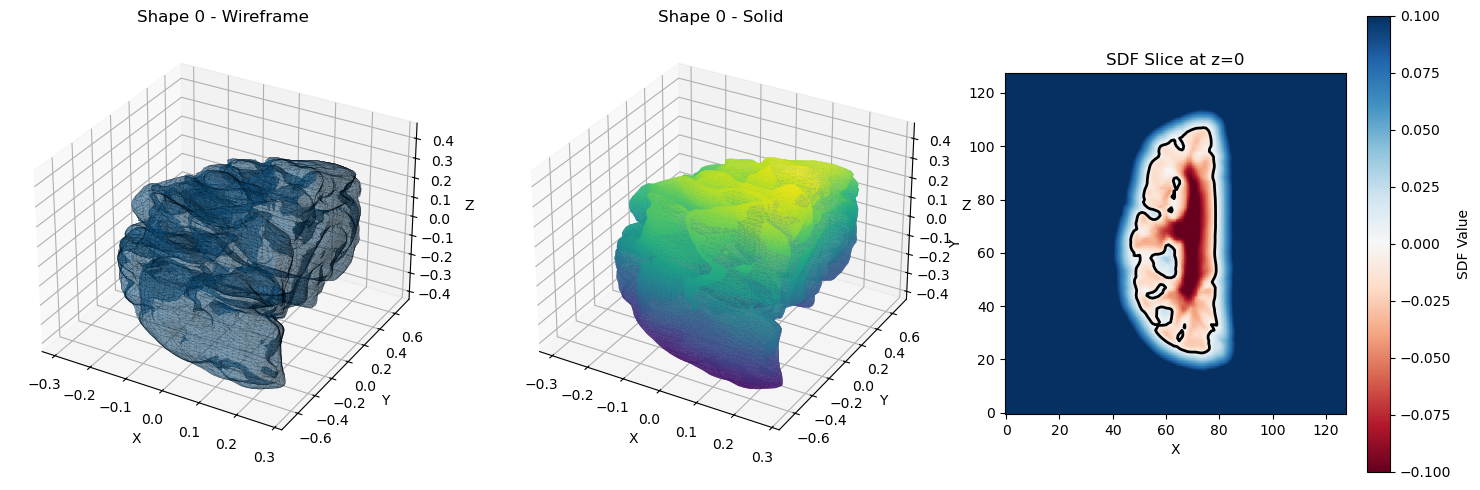

In [31]:
# Plot mesh
fig = plt.figure(figsize=(15, 5))

# Plot 1: Wireframe
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(mesh.vertices[:, 0], mesh.vertices[:, 1], 
                 mesh.vertices[:, 2], triangles=mesh.faces,
                 alpha=0.3, edgecolor='black', linewidth=0.1)
ax1.set_title(f'Shape {shape_idx} - Wireframe')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Plot 2: Solid mesh
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_trisurf(mesh.vertices[:, 0], mesh.vertices[:, 1], 
                 mesh.vertices[:, 2], triangles=mesh.faces,
                 cmap='viridis', alpha=0.9)
ax2.set_title(f'Shape {shape_idx} - Solid')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

# Plot 3: SDF slice at z=0
ax3 = fig.add_subplot(133)
z_slice = resolution // 2
im = ax3.imshow(sdf_grid[:, :, z_slice].T, cmap='RdBu', origin='lower', vmin=-0.1, vmax=0.1)
ax3.contour(sdf_grid[:, :, z_slice].T, levels=[0], colors='black', linewidths=2)
ax3.set_title(f'SDF Slice at z=0')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
plt.colorbar(im, ax=ax3, label='SDF Value')

plt.tight_layout()
plt.show()

## 6. Save Mesh to File

In [33]:
# Save mesh
output_dir = os.path.join(experiment_dir, "Reconstructions")
os.makedirs(output_dir, exist_ok=True)

output_filename = f"shape_{shape_idx:03d}_epoch_{epoch}_res{resolution}.ply"
output_path = os.path.join(output_dir, output_filename)

mesh.export(output_path)

print(f"\n✓ Mesh saved:")
print(f"  File: {output_path}")
print(f"  Size: {os.path.getsize(output_path) / 1024:.2f} KB")
print(f"\nYou can open this file in MeshLab, Blender, or CloudCompare")


✓ Mesh saved:
  File: /home/jakaria/INR/Deep3DComp/examples/CALSNIC_control_L_local/Reconstructions/shape_000_epoch_latest_res128.ply
  Size: 1282.07 KB

You can open this file in MeshLab, Blender, or CloudCompare


## 7. Analyze Global vs Local Code Contributions

In [ ]:
# Visualize code magnitudes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Global code
global_code_np = global_code.cpu().squeeze().numpy()
axes[0].bar(range(len(global_code_np)), np.abs(global_code_np))
axes[0].set_title(f'Global Code Magnitudes (Shape {shape_idx})')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Absolute Value')
axes[0].set_ylim([0, max(np.abs(global_code_np)) * 1.1])

# Local codes - show L2 norm per grid point
local_codes_np = all_local_codes.cpu().squeeze().numpy()
local_norms = np.linalg.norm(local_codes_np, axis=1)
axes[1].hist(local_norms, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title(f'Local Code L2 Norms Distribution')
axes[1].set_xlabel('L2 Norm')
axes[1].set_ylabel('Count')
axes[1].axvline(x=np.mean(local_norms), color='red', linestyle='--', label=f'Mean: {np.mean(local_norms):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nCode Statistics:")
print(f"  Global code L2 norm: {np.linalg.norm(global_code_np):.3f}")
print(f"  Local codes mean L2 norm: {np.mean(local_norms):.3f}")
print(f"  Local codes std L2 norm: {np.std(local_norms):.3f}")
print(f"  Sparse local codes (norm < 0.1): {np.sum(local_norms < 0.1)} / {len(local_norms)}")